# Lista X - Algoritmos de Ordenação

Nesta atividade, você deverá implementar e comparar experimentalmente três algoritmos de ordenação.

O objetivo é analisar se os resultados obtidos na prática, como tempo de execução e quantidade de trocas ou movimentações, estão coerentes com a complexidade teórica dos algoritmos estudados em aula.

## Algoritmos disponíveis

Você deverá escolher três algoritmos entre os seguintes:

- Bubble Sort
- Insertion Sort
- Selection Sort
- Merge Sort
- Quick Sort
- Heap Sort

**Atenção:** Os algoritmos poderão ser implementados em qualquer linguagem de programação. A escolha dos algoritmos deve respeitar a seguinte restrição: os três algoritmos escolhidos não podem ter a mesma complexidade no pior caso. Portanto, o grupo deve selecionar algoritmos com comportamentos assintóticos diferentes. Por exemplo, não é permitido escolher apenas algoritmos quadráticos no pior caso, como Bubble Sort, Insertion Sort e Selection Sort.

## Tamanhos dos vetores

Você deverá gerar vetores com números aleatórios com os seguintes tamanhos:

- 1.000 elementos
- 10.000 elementos
- 100.000 elementos

**Atenção:** para cada tamanho, o mesmo vetor original deverá ser utilizado como entrada para todos os algoritmos. Isso garante uma comparação justa entre os métodos.

## Execução dos testes

Cada ordenação deverá ser executada três vezes.

Para cada algoritmo e para cada tamanho de vetor, você deverá registrar:

- tempo da execução 1
- tempo da execução 2
- tempo da execução 3
- tempo médio
- desvio padrão
- quantidade de trocas ou movimentações realizadas

Todos os tempos devem ser registrados em segundos. Para algoritmos como Bubble Sort, Selection Sort e Quick Sort, uma troca pode ser considerada quando dois elementos mudam de posição. Para algoritmos como Merge Sort, podem ser consideradas as movimentações ou escritas de elementos durante o processo de intercalação.

**Atenção:** Caso algum algoritmo não finalize a execução em até 5 minutos, você deverá interromper o teste e registrar essa informação na planilha.

## Documentação dos Resultados

Todos os resultados obtidos deverão ser registrados na planilha modelo. Além de preencher a planilha, você deverá produzir pelo menos um gráfico a partir dos dados coletados. O tipo de gráfico poderá ser escolhido livremente, desde que ajude a comparar o desempenho dos algoritmos.

## Algoritmos escolhidos

1. **Insertion Sort** — complexidade O(n²) no pior caso, O(n) no melhor caso
2. **Quick Sort** — complexidade O(n²) no pior caso, O(n log n) no caso médio
3. **Merge Sort** — complexidade O(n log n) em todos os casos

Os três algoritmos possuem comportamentos assintóticos distintos: Insertion Sort é claramente O(n²), Merge Sort é garantidamente O(n log n), e Quick Sort apresenta O(n log n) na média com degradação para O(n²) no pior caso.

## 1. Importações e configurações

In [1]:
import time
import random
import copy
import sys
import statistics
import threading
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

sys.setrecursionlimit(300000)
matplotlib.rcParams['figure.dpi'] = 110

TIMEOUT = 300   # 5 minutos por execucao
SIZES   = [1000, 10000, 100000]
N_RUNS  = 3

# Mesmo vetor para todos os algoritmos (reproducibilidade)
random.seed(42)
vectors = {s: [random.randint(0, 10**9) for _ in range(s)] for s in SIZES}
print('Vetores gerados:', {s: f'{len(v)} elementos' for s, v in vectors.items()})

Vetores gerados: {1000: '1000 elementos', 10000: '10000 elementos', 100000: '100000 elementos'}


## 2. Implementação — Insertion Sort

Complexidade: O(n²) pior/médio caso | O(n) melhor caso | Espaço: O(1)

Contagem de movimentações: cada vez que um elemento é deslocado para abrir espaço conta como uma movimentação. O posicionamento final da chave também é contado quando ela realmente muda de lugar.

In [2]:
def insertion_sort(arr):
    """
    Ordena arr in-place usando Insertion Sort.
    Retorna (arr, movimentacoes).
    """
    moves = 0
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]   # desloca elemento
            moves += 1
            j -= 1
        if j + 1 != i:            # key mudou de lugar
            moves += 1
        arr[j + 1] = key
    return arr, moves

# Teste rapido
test = [5, 3, 8, 1, 9, 2]
resultado, mv = insertion_sort(test[:])
print('Insertion Sort teste:', resultado, '| movimentacoes:', mv)

Insertion Sort teste: [1, 2, 3, 5, 8, 9] | movimentacoes: 11


## 3. Implementação — Quick Sort

Complexidade: O(n²) pior caso | O(n log n) caso médio | Espaço: O(log n) na pilha

Contagem de trocas: toda vez que dois elementos trocam de posição no array durante o particionamento conta como uma troca. Usa pivô aleatório para evitar o pior caso em vetores já ordenados. Implementação iterativa via simulação de pilha para evitar estouro de recursão.

In [3]:
def _qs_partition(arr, low, high, counter):
    # Pivô aleatório: evita O(n²) em vetores quase ordenados
    rand_idx = random.randint(low, high)
    arr[rand_idx], arr[high] = arr[high], arr[rand_idx]
    counter[0] += 1
    pivot = arr[high]
    i = low - 1
    for j in range(low, high):
        if arr[j] <= pivot:
            i += 1
            if i != j:
                arr[i], arr[j] = arr[j], arr[i]
                counter[0] += 1
    if i + 1 != high:
        arr[i + 1], arr[high] = arr[high], arr[i + 1]
        counter[0] += 1
    return i + 1

def _qs_helper(arr, low, high, counter):
    # Iterativo com otimizacao tail-call para reduzir profundidade da pilha
    while low < high:
        pi = _qs_partition(arr, low, high, counter)
        if pi - low < high - pi:
            _qs_helper(arr, low, pi - 1, counter)
            low = pi + 1
        else:
            _qs_helper(arr, pi + 1, high, counter)
            high = pi - 1

def quick_sort(arr):
    """
    Ordena arr in-place usando Quick Sort com pivo aleatorio.
    Retorna (arr, trocas).
    """
    counter = [0]
    _qs_helper(arr, 0, len(arr) - 1, counter)
    return arr, counter[0]

# Teste rapido
test = [5, 3, 8, 1, 9, 2]
resultado, tr = quick_sort(test[:])
print('Quick Sort teste:', resultado, '| trocas:', tr)

Quick Sort teste: [1, 2, 3, 5, 8, 9] | trocas: 8


## 4. Implementação — Merge Sort

Complexidade: O(n log n) em todos os casos | Espaço: O(n) auxiliar

Contagem de movimentações: cada escrita no array durante a etapa de intercalação (merge) conta como uma movimentação.

In [4]:
def _merge(arr, left, mid, right):
    L = arr[left:mid + 1]
    R = arr[mid + 1:right + 1]
    i = j = 0
    k = left
    moves = 0
    while i < len(L) and j < len(R):
        if L[i] <= R[j]:
            arr[k] = L[i]; i += 1
        else:
            arr[k] = R[j]; j += 1
        moves += 1; k += 1
    while i < len(L):
        arr[k] = L[i]; i += 1; k += 1; moves += 1
    while j < len(R):
        arr[k] = R[j]; j += 1; k += 1; moves += 1
    return moves

def _merge_sort_rec(arr, left, right):
    if left >= right:
        return 0
    mid = (left + right) // 2
    m  = _merge_sort_rec(arr, left, mid)
    m += _merge_sort_rec(arr, mid + 1, right)
    m += _merge(arr, left, mid, right)
    return m

def merge_sort(arr):
    """
    Ordena arr in-place usando Merge Sort.
    Retorna (arr, movimentacoes).
    """
    moves = _merge_sort_rec(arr, 0, len(arr) - 1)
    return arr, moves

# Teste rapido
test = [5, 3, 8, 1, 9, 2]
resultado, mv = merge_sort(test[:])
print('Merge Sort teste:', resultado, '| movimentacoes:', mv)

Merge Sort teste: [1, 2, 3, 5, 8, 9] | movimentacoes: 16


## 5. Execução dos experimentos

Cada algoritmo é executado 3 vezes sobre cópias do mesmo vetor original. Caso a execução ultrapasse 5 minutos (300 s), ela é interrompida e registrada como N/C.

In [5]:
algorithms = [
    ("Insertion Sort", insertion_sort),
    ("Quick Sort",     quick_sort),
    ("Merge Sort",     merge_sort),
]

results = {}

for algo_name, algo_func in algorithms:
    results[algo_name] = {}
    for size in SIZES:
        run_times = []
        run_moves = []
        timed_out = False

        for run in range(N_RUNS):
            arr = copy.copy(vectors[size])
            slot = [None, None]

            def target(a=arr, f=algo_func, s=slot):
                t0 = time.perf_counter()
                _, mv = f(a)
                s[0] = time.perf_counter() - t0
                s[1] = mv

            th = threading.Thread(target=target, daemon=True)
            th.start()
            th.join(timeout=TIMEOUT)

            if th.is_alive() or slot[0] is None:
                print(f'  TIMEOUT: {algo_name} n={size:,} execucao {run+1} (>5 min)')
                timed_out = True
                break

            run_times.append(slot[0])
            run_moves.append(slot[1])
            print(f'{algo_name}  n={size:>7,}  exec {run+1}: {slot[0]:.6f} s  ops={slot[1]:,}')

        if timed_out:
            results[algo_name][size] = dict(times=None, moves=None, avg=None, std=None)
        else:
            avg = statistics.mean(run_times)
            std = statistics.stdev(run_times) if len(run_times) > 1 else 0.0
            results[algo_name][size] = dict(
                times=run_times,
                moves=int(statistics.mean(run_moves)),
                avg=avg,
                std=std,
            )
            print(f'  -> media={avg:.6f} s  desvio={std:.6f} s  ops={int(statistics.mean(run_moves)):,}\n')

print('\nExperimentos concluidos.')

Insertion Sort  n=  1,000  exec 1: 0.013927 s  ops=244,354
Insertion Sort  n=  1,000  exec 2: 0.013008 s  ops=244,354
Insertion Sort  n=  1,000  exec 3: 0.012746 s  ops=244,354
  -> media=0.013227 s  desvio=0.000620 s  ops=244,354

Insertion Sort  n= 10,000  exec 1: 1.355180 s  ops=25,031,705
Insertion Sort  n= 10,000  exec 2: 1.317580 s  ops=25,031,705
Insertion Sort  n= 10,000  exec 3: 1.295894 s  ops=25,031,705
  -> media=1.322885 s  desvio=0.029997 s  ops=25,031,705

Insertion Sort  n=100,000  exec 1: 164.126409 s  ops=2,495,060,647
Insertion Sort  n=100,000  exec 2: 164.053941 s  ops=2,495,060,647
Insertion Sort  n=100,000  exec 3: 162.896520 s  ops=2,495,060,647
  -> media=163.692290 s  desvio=0.690109 s  ops=2,495,060,647

Quick Sort  n=  1,000  exec 1: 0.000814 s  ops=5,656
Quick Sort  n=  1,000  exec 2: 0.000762 s  ops=4,396
Quick Sort  n=  1,000  exec 3: 0.001028 s  ops=5,730
  -> media=0.000868 s  desvio=0.000141 s  ops=5,260

Quick Sort  n= 10,000  exec 1: 0.010616 s  ops=7

## 6. Tabela de resultados

In [6]:
print(f"{'Algoritmo':<18} {'Complexidade':<22} {'Tamanho':>10}  {'Exec 1 (s)':>12} {'Exec 2 (s)':>12} {'Exec 3 (s)':>12}  {'Media (s)':>12} {'Desvio (s)':>12}  {'Ops':>14}")
print('-' * 130)

complexidades = {
    "Insertion Sort": "O(n²) pior caso",
    "Quick Sort":     "O(n log n) medio",
    "Merge Sort":     "O(n log n) sempre",
}

for algo_name, _ in algorithms:
    for size in SIZES:
        r = results[algo_name][size]
        comp = complexidades[algo_name]
        if r['times'] is None:
            print(f"{algo_name:<18} {comp:<22} {size:>10,}  {'N/C':>12} {'N/C':>12} {'N/C':>12}  {'N/C':>12} {'N/C':>12}  {'N/C':>14}")
        else:
            t = r['times']
            t2 = t[1] if len(t) > 1 else t[0]
            t3 = t[2] if len(t) > 2 else t[0]
            print(f"{algo_name:<18} {comp:<22} {size:>10,}  {t[0]:>12.6f} {t2:>12.6f} {t3:>12.6f}  {r['avg']:>12.6f} {r['std']:>12.6f}  {r['moves']:>14,}")
    print()

Algoritmo          Complexidade              Tamanho    Exec 1 (s)   Exec 2 (s)   Exec 3 (s)     Media (s)   Desvio (s)             Ops
----------------------------------------------------------------------------------------------------------------------------------
Insertion Sort     O(n²) pior caso             1,000      0.013927     0.013008     0.012746      0.013227     0.000620         244,354
Insertion Sort     O(n²) pior caso            10,000      1.355180     1.317580     1.295894      1.322885     0.029997      25,031,705
Insertion Sort     O(n²) pior caso           100,000    164.126409   164.053941   162.896520    163.692290     0.690109   2,495,060,647

Quick Sort         O(n log n) medio            1,000      0.000814     0.000762     0.001028      0.000868     0.000141           5,260
Quick Sort         O(n log n) medio           10,000      0.010616     0.011980     0.012157      0.011584     0.000844          79,653
Quick Sort         O(n log n) medio          100,000

## 7. Gráficos comparativos

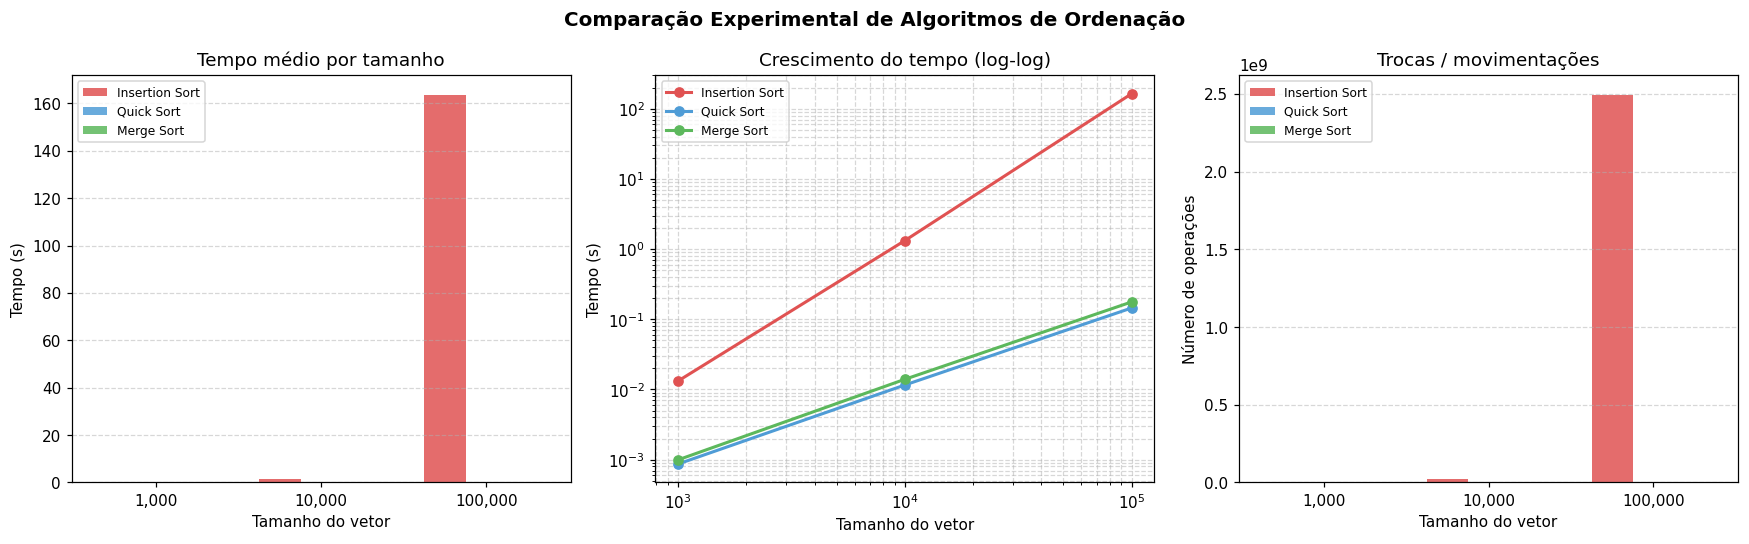

Grafico salvo em C:\Users\Caio\Downloads\ex\grafico_comparativo.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparação Experimental de Algoritmos de Ordenação', fontsize=13, fontweight='bold')

cores  = {'Insertion Sort': '#e05252', 'Quick Sort': '#4f9cd6', 'Merge Sort': '#5cb85c'}
labels = [f'{s:,}' for s in SIZES]
x      = np.arange(len(SIZES))
width  = 0.25

# --- Grafico 1: tempo medio por tamanho (barras agrupadas) ---
ax = axes[0]
for idx, (name, _) in enumerate(algorithms):
    vals = []
    for size in SIZES:
        r = results[name][size]
        vals.append(r['avg'] if r['avg'] is not None else 0)
    bars = ax.bar(x + idx * width, vals, width, label=name, color=cores[name], alpha=0.85)
ax.set_title('Tempo médio por tamanho')
ax.set_xlabel('Tamanho do vetor')
ax.set_ylabel('Tempo (s)')
ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# --- Grafico 2: tempo medio com escala logaritmica ---
ax2 = axes[1]
for name, _ in algorithms:
    xs, ys = [], []
    for size in SIZES:
        r = results[name][size]
        if r['avg'] is not None:
            xs.append(size)
            ys.append(r['avg'])
    if xs:
        ax2.plot(xs, ys, marker='o', label=name, color=cores[name], linewidth=2)
ax2.set_title('Crescimento do tempo (log-log)')
ax2.set_xlabel('Tamanho do vetor')
ax2.set_ylabel('Tempo (s)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend(fontsize=8)
ax2.grid(True, which='both', linestyle='--', alpha=0.5)

# --- Grafico 3: operacoes (trocas/movimentacoes) ---
ax3 = axes[2]
for idx, (name, _) in enumerate(algorithms):
    vals = []
    for size in SIZES:
        r = results[name][size]
        vals.append(r['moves'] if r['moves'] is not None else 0)
    ax3.bar(x + idx * width, vals, width, label=name, color=cores[name], alpha=0.85)
ax3.set_title('Trocas / movimentações')
ax3.set_xlabel('Tamanho do vetor')
ax3.set_ylabel('Número de operações')
ax3.set_xticks(x + width)
ax3.set_xticklabels(labels)
ax3.legend(fontsize=8)
ax3.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(r'C:\Users\Caio\Downloads\ex\grafico_comparativo.png', bbox_inches='tight')
plt.show()
print('Grafico salvo em C:\\Users\\Caio\\Downloads\\ex\\grafico_comparativo.png')